<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_DataEfficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flettner Rotor PINN — Data Efficiency Study
**Same parameters as NCp=8 best run. Varies NCp = 0, 4, 8, 16, 30.**

- Re=3.6e5, α=2.0, N_INT=2000, EPOCHS=6000
- Each run produces identical plots: loss, Cp with sensor markers, force bars
- Results saved to Drive after each run (resume-safe)

**Run cells in order: 1 → 2 → 3 → 4 → 5 → 6**

## Section 1 — Setup and Parameters

In [1]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1: PARAMETERS
# All tunable settings in one place. Change only here.
# ─────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)

import os, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":11, "figure.dpi":120})

# ── Physics ───────────────────────────────────────────────────────
RE    = 3.6e5       # Reynolds number
NU    = 1.0 / RE    # kinematic viscosity (non-dimensional)
ALPHA = 2.0         # spin ratio

# ── Domain (non-dimensional, D=1) ────────────────────────────────
R_IN  = 0.5         # cylinder radius = D/2
R_OUT = 25.0        # far-field radius = 25D

# ── Data efficiency study ─────────────────────────────────────────
# NCp = number of Cp points used for training
# None = all available Bordogna points (30 for alpha=2)
# 0    = no Cp data (physics only)
SPARSITY_LIST = [0, 4, 8, 16, None]   # all conditions to run

# Sensor angles for each NCp (computed in Section 2 after data load)

# ── Collocation points ────────────────────────────────────────────
N_INT  = 2000       # interior points (log-polar) — do NOT reduce below 1500
N_WALL =  300       # wall points
N_FF   =  150       # far-field points

# ── Training ─────────────────────────────────────────────────────
EPOCHS  = 6000      # more epochs for better convergence
LR      = 1e-4      # learning rate

# ── Loss weights (physics >> BCs >> data) ────────────────────────
W_PDE   = 100.0     # NS momentum + continuity
W_VWALL = 300.0     # wall rotation BC — high: drives Magnus effect
W_VFF   =  10.0     # far-field u=1, v=0
W_PP    =  50.0     # mean far-field pressure = 0 (gauge reference)
W_CP    =  10.0     # Cp sensor data (raised from 5 for better Cp fit)
W_TURB  =   1.0     # k-omega SST equations

DATA_DIR = "/content/drive/MyDrive/P-PINN"
OUT_DIR  = "/content/drive/MyDrive/PINN_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"TensorFlow {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Re={RE:.1e}  alpha={ALPHA}  nu={NU:.3e}")
print(f"Domain: R_IN={R_IN}  R_OUT={R_OUT} (=25D)")
print(f"Sparsity runs: {SPARSITY_LIST}")
print(f"Collocation: {N_INT} interior + {N_WALL} wall + {N_FF} far-field")
print(f"Training: {EPOCHS} epochs, LR={LR}")


Mounted at /content/drive
TensorFlow 2.20.0 | GPU: True
Re=3.6e+05  alpha=2.0  nu=2.778e-06
Domain: R_IN=0.5  R_OUT=25.0 (=25D)
Sparsity runs: [0, 4, 8, 16, None]
Collocation: 2000 interior + 300 wall + 150 far-field
Training: 6000 epochs, LR=0.0001


## Section 2 — Load Experimental Data

Loading experimental data...
  Full Cp data: 30 points
  Stagnation:   theta=331°  Cp_max=1.35
  Suction peak: theta=109°  Cp_min=-6.39
  Exp forces:   CL=5.917  CD=1.745
  Full Cp data: 30 points available for training


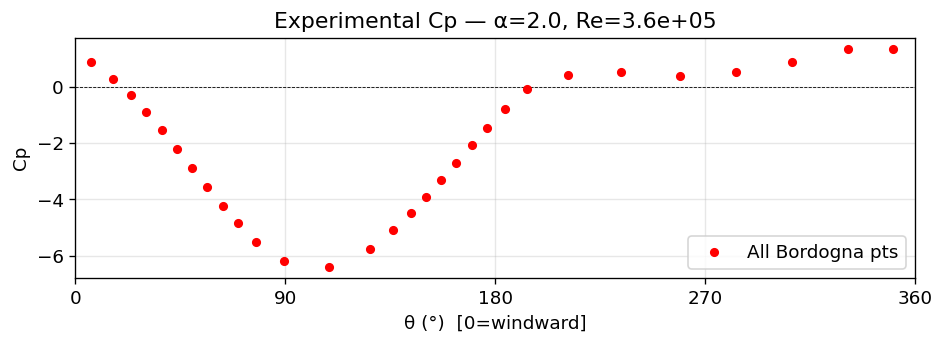

Data loaded ✓


In [3]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2: LOAD EXPERIMENTAL DATA
# Loads Cp, CL, CD from Bordogna et al. (2019) Excel files.
# Cp convention: theta=0 at windward (left), theta=90 at top.
# ─────────────────────────────────────────────────────────────────

RE_COL_MAP = {
    1.8e5:{0,12,24,36,48,60}, 2.5e5:{3,15,27,39,51,63,69,75,81,87,93},
    3.6e5:{6,18,30,42,54,72,78,84,90,96}, 1.0e6:{9,21,33,45,57,66},
}

def load_cp(folder, re_target, alpha_target, tol=0.1):
    for nm in ["CP_data.xlsx", "CP data.xlsx"]:
        p = os.path.join(folder, nm)
        if os.path.exists(p): break
    raw  = pd.read_excel(p, sheet_name="Master Data", header=None)
    row0 = raw.iloc[0]
    for col in range(0, len(row0)-1, 3):
        label = str(row0.iloc[col])
        if "k =" not in label: continue
        try: k_val = float(label.split(",")[0].replace("k =","").strip())
        except: continue
        if abs(k_val - alpha_target) > tol: continue
        re_match = None
        for rv, cs in RE_COL_MAP.items():
            if col in cs: re_match = rv; break
        if re_match is None or abs(re_match - re_target) > re_target*0.1: continue
        th = pd.to_numeric(raw.iloc[2:, col],   errors="coerce").values
        cp = pd.to_numeric(raw.iloc[2:, col+1], errors="coerce").values
        mask = ~np.isnan(th) & ~np.isnan(cp)
        if mask.sum() < 3: continue
        return th[mask].astype(np.float32), cp[mask].astype(np.float32)
    raise ValueError(f"No Cp data for alpha={alpha_target}, Re={re_target:.2e}")

def load_cl_cd(folder, re_target):
    sheet = {1.8e5:"Re=1.8e5", 2.5e5:"Re=2.5e5", 3.6e5:"Re=3.6e5",
             5.5e5:"Re=5.5e5", 1.0e6:"Re=1e6"}[
             min({1.8e5,2.5e5,3.6e5,5.5e5,1.0e6}, key=lambda r: abs(r-re_target))]
    for nm in ["CL_data.xlsx","CL data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cl_path=p; break
    for nm in ["CD_data.xlsx","CD data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cd_path=p; break
    df_cl = pd.read_excel(cl_path, sheet_name=sheet, header=None)
    df_cd = pd.read_excel(cd_path, sheet_name=sheet, header=None)
    df_cl.columns = ["alpha","CL"] + list(df_cl.columns[2:])
    df_cd.columns = ["alpha","CD"] + list(df_cd.columns[2:])
    return (df_cl["alpha"].dropna().values.astype(np.float32),
            df_cl["CL"].dropna().values.astype(np.float32),
            df_cd["alpha"].dropna().values.astype(np.float32),
            df_cd["CD"].dropna().values.astype(np.float32))

# Load
print("Loading experimental data...")
theta_exp, cp_exp = load_cp(DATA_DIR, RE, ALPHA)
al_cl, CL_exp, al_cd, CD_exp = load_cl_cd(DATA_DIR, RE)

tol = 0.25
cl_ref = float(CL_exp[np.abs(al_cl - ALPHA) < tol].mean())
cd_ref = float(CD_exp[np.abs(al_cd - ALPHA) < tol].mean())

# Sensor angles computed per run in Section 4
# (placeholder — actual sensors set inside training loop)

print(f"  Full Cp data: {len(theta_exp)} points")
print(f"  Stagnation:   theta={theta_exp[np.argmax(cp_exp)]:.0f}°  Cp_max={cp_exp.max():.2f}")
print(f"  Suction peak: theta={theta_exp[np.argmin(cp_exp)]:.0f}°  Cp_min={cp_exp.min():.2f}")
print(f"  Exp forces:   CL={cl_ref:.3f}  CD={cd_ref:.3f}")
# print(f"\n  Sensor values at theta={SENSOR_ANGLES.tolist()}:")
# for th, cp in zip(SENSOR_ANGLES, cp_sensors):
#     print(f"    theta={th:5.1f}°  Cp={cp:+.3f}")

# Quick data plot with sensor positions marked
fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(theta_exp, cp_exp, color="red", s=20, zorder=5, label="All Bordogna pts")
ax.axhline(0, color="k", lw=0.5, ls="--")
ax.set_xlabel("θ (°)  [0=windward]"); ax.set_ylabel("Cp")
ax.set_title(f"Experimental Cp — α={ALPHA}, Re={RE:.1e}")
ax.set_xlim([0,360]); ax.set_xticks([0,90,180,270,360])
ax.legend(); ax.grid(True, alpha=0.3)
print(f"  Full Cp data: {len(theta_exp)} points available for training")
plt.tight_layout(); plt.show()
print("Data loaded ✓")


## Section 3 — Model Builder and Shared Functions

In [4]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3: MODEL BUILDER AND SHARED FUNCTIONS
# build_model() creates a fresh network for each sparsity run.
# Shared geometry (wall, far-field points) computed once here.
# ─────────────────────────────────────────────────────────────────
import tensorflow as tf

def build_model():
    """Build a fresh 6x64 tanh network. Called once per sparsity run."""
    tf.keras.backend.clear_session()
    inp  = tf.keras.Input(shape=(3,), name="xya")
    h    = inp
    for i in range(6):
        h = tf.keras.layers.Dense(64, activation="tanh", name=f"h{i+1}")(h)
    uvp  = tf.keras.layers.Dense(3, activation=None,       name="uvp")(h)
    komg = tf.keras.layers.Dense(2, activation="softplus", name="komg")(h)
    return tf.keras.Model(inputs=inp, outputs=[uvp, komg])

def get_uvp(out): return out[0]
def get_ko(out):  return out[1]
def mse(a, b=0.0): return tf.reduce_mean(tf.square(a - b))

# ── k-omega SST constants (Menter 1994) ──────────────────────────
C = dict(
    NU    = tf.constant(float(NU),   dtype=tf.float32),
    BSTAR = tf.constant(0.09,        dtype=tf.float32),
    BETA2 = tf.constant(0.0828,      dtype=tf.float32),
    SK2   = tf.constant(1.00,        dtype=tf.float32),
    SO2   = tf.constant(0.856,       dtype=tf.float32),
    GAM2  = tf.constant(0.0828/0.09 - 0.856*0.41**2/0.09**0.5, dtype=tf.float32),
    EPS   = tf.constant(1e-8,        dtype=tf.float32),
    KW    = tf.constant(0.0,         dtype=tf.float32),
    OW    = tf.constant(60.0*float(NU), dtype=tf.float32),
    KI    = tf.constant(1.5e-4,      dtype=tf.float32),
    OI    = tf.constant(2.0,         dtype=tf.float32),
)

# ── Coordinate helpers ────────────────────────────────────────────
def make_input(x, y):
    a = np.full_like(x, ALPHA/5.0, dtype=np.float32)
    return tf.constant(np.hstack([x, y, a]))

def sample_interior(n):
    th = np.random.uniform(0, 2*np.pi, n).astype(np.float32)
    r  = np.exp(np.random.uniform(np.log(R_IN), np.log(R_OUT), n)).astype(np.float32)
    return (r*np.cos(th)).reshape(-1,1), (r*np.sin(th)).reshape(-1,1)

def sample_wall(n):
    th = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    return (-R_IN*np.cos(th)).reshape(-1,1), (+R_IN*np.sin(th)).reshape(-1,1)

def sample_ff(n):
    th = np.linspace(0, 2*np.pi, n, endpoint=False, dtype=np.float32)
    return (R_OUT*np.cos(th)).reshape(-1,1), (R_OUT*np.sin(th)).reshape(-1,1)

# ── Pre-compute fixed boundary points (same for all runs) ─────────
Omega   = float(ALPHA / R_IN)
xw, yw  = sample_wall(N_WALL)
xff,yff = sample_ff(N_FF)
xw_tf   = make_input(xw, yw)
xff_tf  = make_input(xff, yff)
u_wall  = tf.constant(( Omega*yw).astype(np.float32))
v_wall  = tf.constant((-Omega*xw).astype(np.float32))

# Verify model builds correctly
_test = build_model()
print(f"Model: 6x64 tanh | Parameters: {_test.count_params():,}")
print(f"Omega={Omega:.2f}  Wall points={N_WALL}  FF points={N_FF}")
print("Section 3 done ✓")


Model: 6x64 tanh | Parameters: 21,381
Omega=4.00  Wall points=300  FF points=150
Section 3 done ✓


## Section 4 — Training All Sparsity Conditions

In [5]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4: TRAINING LOOP
# Runs all sparsity conditions in sequence.
# Identical hyperparameters to NCp=8 best run.
# Results saved to Drive after each run — resume-safe.
# ─────────────────────────────────────────────────────────────────
import time, json as _json, os as _os

RESULTS_FILE = f"{OUT_DIR}/data_efficiency_alpha{ALPHA}.json"

# Load previous results if resuming after disconnect
if _os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f:
        all_results = _json.load(f)
    print(f"Resuming — {len(all_results)} runs already completed:")
    for k,v in all_results.items():
        print(f"  ✓ NCp={k}: MAE={v['mae']:.3f}  CL={v['CL']:.3f}  CD={v['CD']:.3f}")
else:
    all_results = {}
    print("Starting fresh — no previous results found")

print()

def get_sensor_config(n_cp):
    """Return (sensor_angles, cp_values, label) for given NCp."""
    if n_cp == 0:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32), "NCp=0 (physics only)"
    elif n_cp is None:
        return theta_exp.copy(), cp_exp.copy(), f"NCp=full ({len(theta_exp)} pts)"
    else:
        angles = np.linspace(0, 360, n_cp, endpoint=False, dtype=np.float32)
        cp_at  = np.interp(angles, theta_exp, cp_exp).astype(np.float32)
        return angles, cp_at, f"NCp={n_cp}"

def run_training(n_cp):
    """Full training run for one sparsity condition. Returns results dict."""
    sensor_angles, cp_values, label = get_sensor_config(n_cp)
    has_cp = len(sensor_angles) > 0

    # Build Cp tensors if sensors exist
    if has_cp:
        th_rad = np.radians(sensor_angles).astype(np.float32)
        x_s = (-R_IN*np.cos(th_rad)).reshape(-1,1)
        y_s = (+R_IN*np.sin(th_rad)).reshape(-1,1)
        xy_sens_tf = make_input(x_s, y_s)
        cp_sens_tf = tf.constant(cp_values.reshape(-1,1))

    model     = build_model()
    optimizer = tf.keras.optimizers.Adam(LR)
    EPS_FD    = 1e-3
    hist      = {k:[] for k in ["loss","pde","wall","ff","cp","turb","epoch"]}
    best_loss, best_w = np.inf, None
    t0 = time.time()

    for ep in range(EPOCHS):
        x_int,y_int = sample_interior(N_INT)
        xy_var = tf.Variable(make_input(x_int,y_int), trainable=False, dtype=tf.float32)
        tr     = float(min(1.0, max(0.0, (ep-1000)/1000.0)))
        tr_tf  = tf.constant(tr, dtype=tf.float32)

        with tf.GradientTape() as outer_tape:
            with tf.GradientTape(watch_accessed_variables=False,
                                 persistent=True) as inner_tape:
                inner_tape.watch(xy_var)
                out = model(xy_var, training=True)
                uvp_int = get_uvp(out)
                u,v,p   = uvp_int[:,0:1],uvp_int[:,1:2],uvp_int[:,2:3]
                if tr > 0:
                    ko=get_ko(out); k=ko[:,0:1]+C["EPS"]; omg=ko[:,1:2]+C["EPS"]

            du_dxy=inner_tape.gradient(u,xy_var); dv_dxy=inner_tape.gradient(v,xy_var)
            dp_dxy=inner_tape.gradient(p,xy_var)
            du_dx=du_dxy[:,0:1]; du_dy=du_dxy[:,1:2]
            dv_dx=dv_dxy[:,0:1]; dv_dy=dv_dxy[:,1:2]
            dp_dx=dp_dxy[:,0:1]; dp_dy=dp_dxy[:,1:2]
            del inner_tape

            nu_t  = tr_tf*tf.clip_by_value(k/(omg+C["EPS"]),0.,0.1) if tr>0 else tf.constant(0.)
            nu_eff = C["NU"] + nu_t

            dX=tf.constant(np.hstack([np.full((N_INT,1),EPS_FD),np.zeros((N_INT,1)),np.zeros((N_INT,1))]).astype(np.float32))
            dY=tf.constant(np.hstack([np.zeros((N_INT,1)),np.full((N_INT,1),EPS_FD),np.zeros((N_INT,1))]).astype(np.float32))
            oxp=model(xy_var+dX,training=True); oxm=model(xy_var-dX,training=True)
            oyp=model(xy_var+dY,training=True); oym=model(xy_var-dY,training=True)
            uxp=get_uvp(oxp); uxm=get_uvp(oxm); uyp=get_uvp(oyp); uym=get_uvp(oym)
            ie2=1./(EPS_FD**2)
            d2u_dx2=(uxp[:,0:1]-2*u+uxm[:,0:1])*ie2; d2u_dy2=(uyp[:,0:1]-2*u+uym[:,0:1])*ie2
            d2v_dx2=(uxp[:,1:2]-2*v+uxm[:,1:2])*ie2; d2v_dy2=(uyp[:,1:2]-2*v+uym[:,1:2])*ie2

            r_cont=du_dx+dv_dy
            r_xmom=u*du_dx+v*du_dy+dp_dx-nu_eff*(d2u_dx2+d2u_dy2)
            r_ymom=u*dv_dx+v*dv_dy+dp_dy-nu_eff*(d2v_dx2+d2v_dy2)
            loss_pde=mse(r_cont)+mse(r_xmom)+mse(r_ymom)

            loss_turb=tf.constant(0.)
            if tr > 0:
                kxp=get_ko(oxp); kxm=get_ko(oxm); kyp=get_ko(oyp); kym=get_ko(oym)
                inv2=.5/EPS_FD
                dk_dx=(kxp[:,0:1]-kxm[:,0:1])*inv2; dk_dy=(kyp[:,0:1]-kym[:,0:1])*inv2
                do_dx=(kxp[:,1:2]-kxm[:,1:2])*inv2; do_dy=(kyp[:,1:2]-kym[:,1:2])*inv2
                d2k_dx2=(kxp[:,0:1]-2*k+kxm[:,0:1])*ie2; d2k_dy2=(kyp[:,0:1]-2*k+kym[:,0:1])*ie2
                d2o_dx2=(kxp[:,1:2]-2*omg+kxm[:,1:2])*ie2; d2o_dy2=(kyp[:,1:2]-2*omg+kym[:,1:2])*ie2
                S2=2*(du_dx**2+dv_dy**2)+(du_dy+dv_dx)**2
                Pk=tf.clip_by_value(nu_t*S2,0.,20.*C["BSTAR"]*k*omg)
                nk=C["NU"]+C["SK2"]*nu_t; no=C["NU"]+C["SO2"]*nu_t
                crs=2.*C["SO2"]/(omg+C["EPS"])*(dk_dx*do_dx+dk_dy*do_dy)
                rk=u*dk_dx+v*dk_dy-Pk+C["BSTAR"]*omg*k-nk*(d2k_dx2+d2k_dy2)
                ro=u*do_dx+v*do_dy-C["GAM2"]*(omg/(k+C["EPS"]))*Pk+C["BETA2"]*omg**2-no*(d2o_dx2+d2o_dy2)-crs
                loss_turb=tr_tf*(mse(tf.clip_by_value(rk,-100.,100.))+
                                 mse(tf.clip_by_value(ro,-100.,100.)))

            out_w=model(xw_tf,training=True); uvp_w=get_uvp(out_w)
            loss_wall=mse(uvp_w[:,0:1],u_wall)+mse(uvp_w[:,1:2],v_wall)
            if tr>0:
                ko_w=get_ko(out_w)
                loss_wall+=tr_tf*(mse(ko_w[:,0:1],C["KW"])+mse(ko_w[:,1:2],C["OW"]))

            out_ff=model(xff_tf,training=True); uvp_ff=get_uvp(out_ff)
            loss_ff=mse(uvp_ff[:,0:1],1.)+mse(uvp_ff[:,1:2])
            p_ff_mean=tf.reduce_mean(uvp_ff[:,2:3])
            loss_pp=tf.square(p_ff_mean)
            if tr>0:
                ko_ff=get_ko(out_ff)
                loss_ff+=tr_tf*(mse(ko_ff[:,0:1],C["KI"])+mse(ko_ff[:,1:2],C["OI"]))

            if has_cp:
                out_cp=model(xy_sens_tf,training=True); uvp_cp=get_uvp(out_cp)
                cp_pred=2.*(uvp_cp[:,2:3]-p_ff_mean)
                loss_cp=mse(cp_pred,cp_sens_tf)
            else:
                loss_cp=tf.constant(0.)

            loss=(W_PDE*loss_pde+W_VWALL*loss_wall+W_VFF*loss_ff+
                  W_PP*loss_pp+W_CP*loss_cp+W_TURB*loss_turb)

        grads=outer_tape.gradient(loss,model.trainable_variables)
        grads,_=tf.clip_by_global_norm(grads,5.)
        optimizer.apply_gradients(zip(grads,model.trainable_variables))

        L=float(loss)
        if not np.isnan(L) and L<best_loss:
            best_loss=L; best_w=model.get_weights()

        if ep%500==0:
            phase="TURB" if tr>0 else "lam "
            hist["loss"].append(L); hist["pde"].append(float(loss_pde))
            hist["wall"].append(float(loss_wall)); hist["ff"].append(float(loss_ff))
            hist["cp"].append(float(loss_cp)); hist["turb"].append(float(loss_turb))
            hist["epoch"].append(ep)
            print(f"  ep {ep:5d} [{phase} r={tr:.2f}] L={L:.3f} "
                  f"pde={float(loss_pde):.4f} wall={float(loss_wall):.4f} "
                  f"cp={float(loss_cp):.4f} | {time.time()-t0:.0f}s")
        if ep==3000:
            optimizer.learning_rate.assign(3e-5)

    elapsed=(time.time()-t0)/60.
    if best_w: model.set_weights(best_w)
    ncp_str = str(n_cp) if n_cp is not None else "full"
    model.save_weights(f"{OUT_DIR}/eff_{ncp_str}.weights.h5")

    # Evaluate
    def get_p_ref(n=256):
        th=np.linspace(0,2*np.pi,n,dtype=np.float32)
        xy=make_input((R_OUT*np.cos(th)).reshape(-1,1),(R_OUT*np.sin(th)).reshape(-1,1))
        return float(get_uvp(model(xy,training=False)).numpy()[:,2].mean())

    th_deg=np.linspace(0,360,360,dtype=np.float32)
    th_rad=np.radians(th_deg)
    x_e=(-R_IN*np.cos(th_rad)).reshape(-1,1); y_e=(+R_IN*np.sin(th_rad)).reshape(-1,1)
    uvp_e=get_uvp(model(make_input(x_e,y_e),training=False)).numpy()
    pr=get_p_ref()
    Cp_raw=2.*(uvp_e[:,2]-pr)
    Cp=Cp_raw+(float(cp_exp.max())-Cp_raw.max())
    mae=float(np.mean(np.abs(np.interp(theta_exp,th_deg,Cp)-cp_exp)))

    # Forces
    n_f=512; dth_f=2*np.pi/n_f
    th_f=np.linspace(0,2*np.pi,n_f,endpoint=False,dtype=np.float32)
    xf=(-R_IN*np.cos(th_f)).reshape(-1,1); yf=(+R_IN*np.sin(th_f)).reshape(-1,1)
    nx=xf/R_IN; ny=yf/R_IN
    p_shift=(float(cp_exp.max())-Cp_raw.max())/2.
    def uv_f(xp,yp):
        o=get_uvp(model(make_input(xp,yp),training=False)).numpy()
        return o[:,0:1],o[:,1:2],o[:,2:3]
    u0,v0,p0=uv_f(xf,yf); p0=p0-pr-p_shift
    uxp,vxp,_=uv_f(xf+1e-3,yf); uxm,vxm,_=uv_f(xf-1e-3,yf)
    uyp,vyp,_=uv_f(xf,yf+1e-3); uym,vym,_=uv_f(xf,yf-1e-3)
    du_dx=(uxp-uxm)/2e-3; du_dy=(uyp-uym)/2e-3
    dv_dx=(vxp-vxm)/2e-3; dv_dy=(vyp-vym)/2e-3
    nu_v=float(NU)
    txx=2*nu_v*du_dx; txy=nu_v*(du_dy+dv_dx); tyy=2*nu_v*dv_dy
    CL=float((np.sum(-p0*ny*R_IN*dth_f)+np.sum((txy*nx+tyy*ny)*R_IN*dth_f))/0.5)
    CD=float((np.sum(-p0*nx*R_IN*dth_f)+np.sum((txx*nx+txy*ny)*R_IN*dth_f))/0.5)

    return {
        "label": label, "n_cp": n_cp,
        "mae": mae, "CL": CL, "CD": CD,
        "Cp_pred": Cp.tolist(), "th_deg": th_deg.tolist(),
        "sensor_angles": sensor_angles.tolist(),
        "cp_values":     cp_values.tolist(),
        "history": {k:[float(v) for v in vals] for k,vals in hist.items()},
        "elapsed": elapsed,
    }

# ── Main loop ─────────────────────────────────────────────────────
for n_cp in SPARSITY_LIST:
    ncp_str = str(n_cp) if n_cp is not None else "full"
    if ncp_str in all_results:
        print(f"  ✓ SKIP NCp={ncp_str} (already done)")
        continue
    print(f"\n{'='*55}")
    print(f"  RUNNING: NCp={ncp_str}")
    print(f"{'='*55}")
    res = run_training(n_cp)
    all_results[ncp_str] = res
    with open(RESULTS_FILE, 'w') as f:
        _json.dump(all_results, f, indent=2)
    print(f"  ✓ Done in {res['elapsed']:.1f} min | MAE={res['mae']:.3f} CL={res['CL']:.3f} CD={res['CD']:.3f}")
    print(f"  Saved to Drive ✓")

print(f"\n{'='*55}")
print(f"ALL RUNS COMPLETE ({len(all_results)}/{len(SPARSITY_LIST)})")
print(f"{'='*55}")

# Convert lists back to arrays for plotting
for k in all_results:
    all_results[k]["Cp_pred"]      = np.array(all_results[k]["Cp_pred"])
    all_results[k]["th_deg"]       = np.array(all_results[k]["th_deg"])
    all_results[k]["sensor_angles"]= np.array(all_results[k]["sensor_angles"])
    all_results[k]["cp_values"]    = np.array(all_results[k]["cp_values"])


Starting fresh — no previous results found


  RUNNING: NCp=0


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['komg/kernel', 'komg/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  ep     0 [lam  r=0.00] L=1206.797 pde=0.0542 wall=3.9558 cp=0.0000 | 2s
  ep   500 [lam  r=0.00] L=2.522 pde=0.0102 wall=0.0000 cp=0.0000 | 158s
  ep  1000 [lam  r=0.00] L=0.599 pde=0.0050 wall=0.0000 cp=0.0000 | 309s
  ep  1500 [TURB r=0.50] L=9.736 pde=0.0338 wall=0.0042 cp=0.0000 | 502s
  ep  2000 [TURB r=1.00] L=8.320 pde=0.0550 wall=0.0064 cp=0.0000 | 693s
  ep  2500 [TURB r=1.00] L=0.779 pde=0.0048 wall=0.0005 cp=0.0000 | 885s
  ep  3000 [TURB r=1.00] L=0.401 pde=0.0025 wall=0.0002 cp=0.0000 | 1076s
  ep  3500 [TURB r=1.00] L=0.289 pde=0.0018 wall=0.0001 cp=0.0000 | 1267s
  ep  4000 [TURB r=1.00] L=0.227 pde=0.0014 wall=0.0001 cp=0.0000 | 1457s
  ep  4500 [TURB r=1.00] L=0.186 pde=0.0012 wall=0.0001 cp=0.0000 | 1647s
  ep  5000 [TURB r=1.00] L=0.154 pde=0.0010 wall=0.0000 cp=0.0000 | 1838s
  ep  5500 [TURB r=1.00] L=0.131 pde=0.0008 wall=0.0000 cp=0.0000 | 2030s
  ✓ Done in 37.0 min | MAE=3.381 CL=0.038 CD=-0.019
  Saved to Drive ✓

  RUNNING: NCp=4
  ep     0 [lam  r=0.00] L=1

## Section 5 — Per-Run Plots (identical layout to NCp=8)

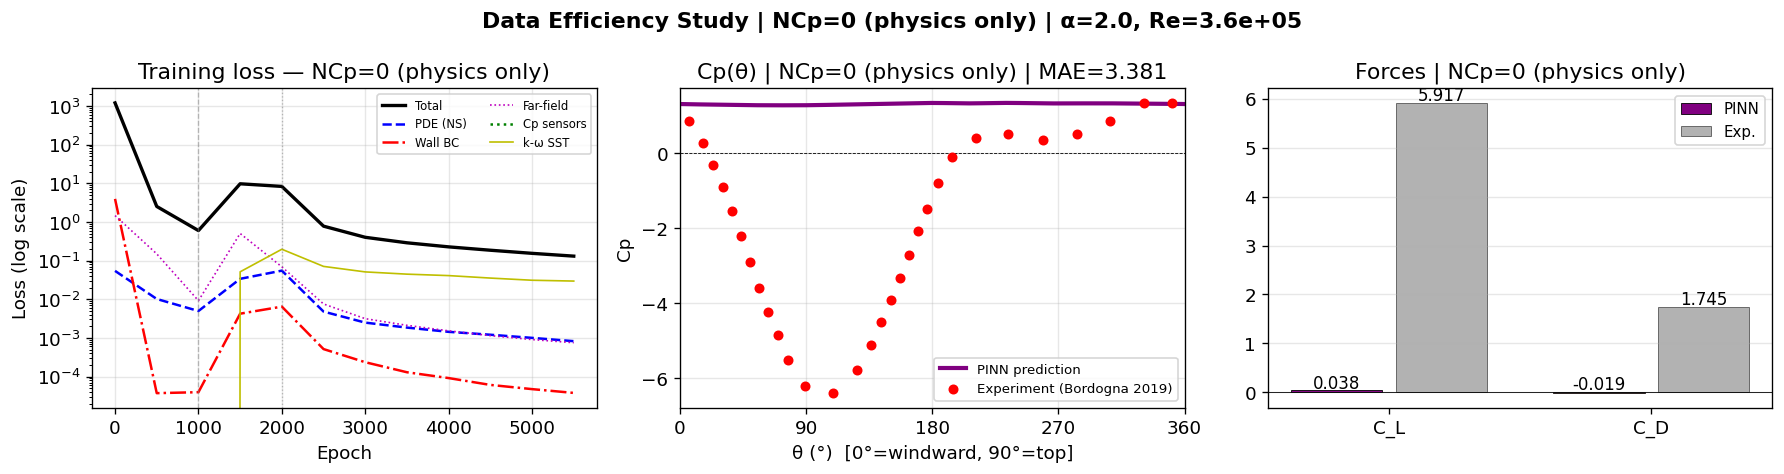

Saved: efficiency_0.png
  MAE=3.381  CL=0.038 (err=99.4%)  CD=-0.019 (err=101.1%)



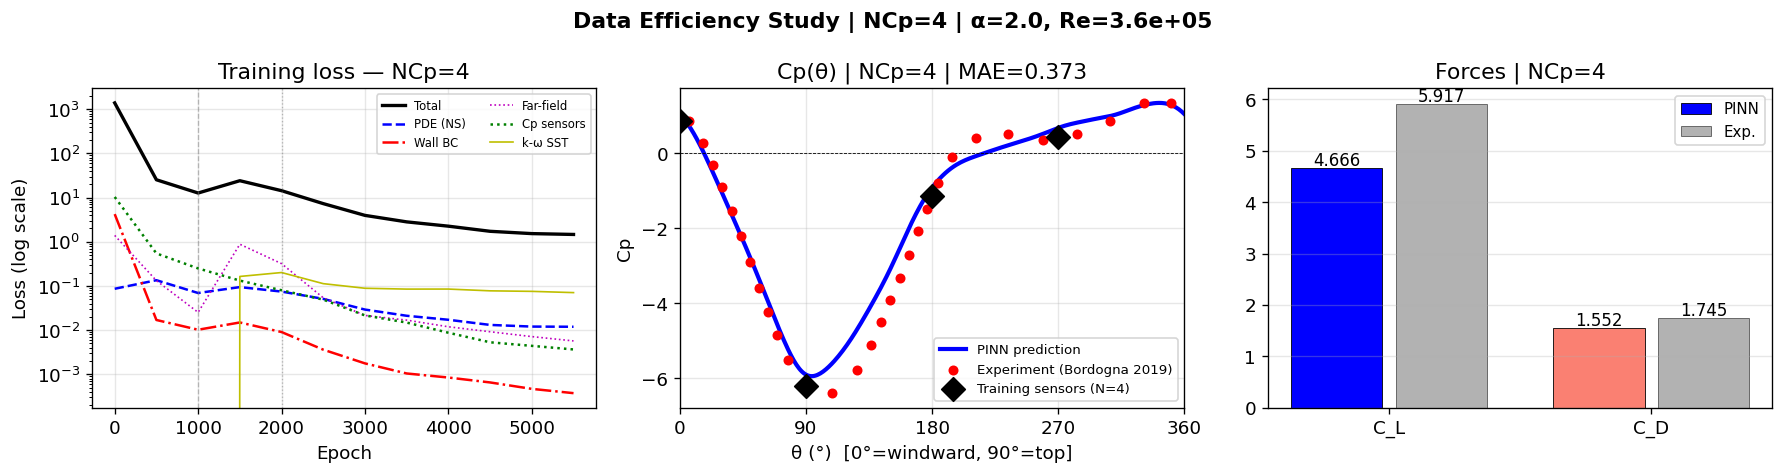

Saved: efficiency_4.png
  MAE=0.373  CL=4.666 (err=21.1%)  CD=1.552 (err=11.0%)



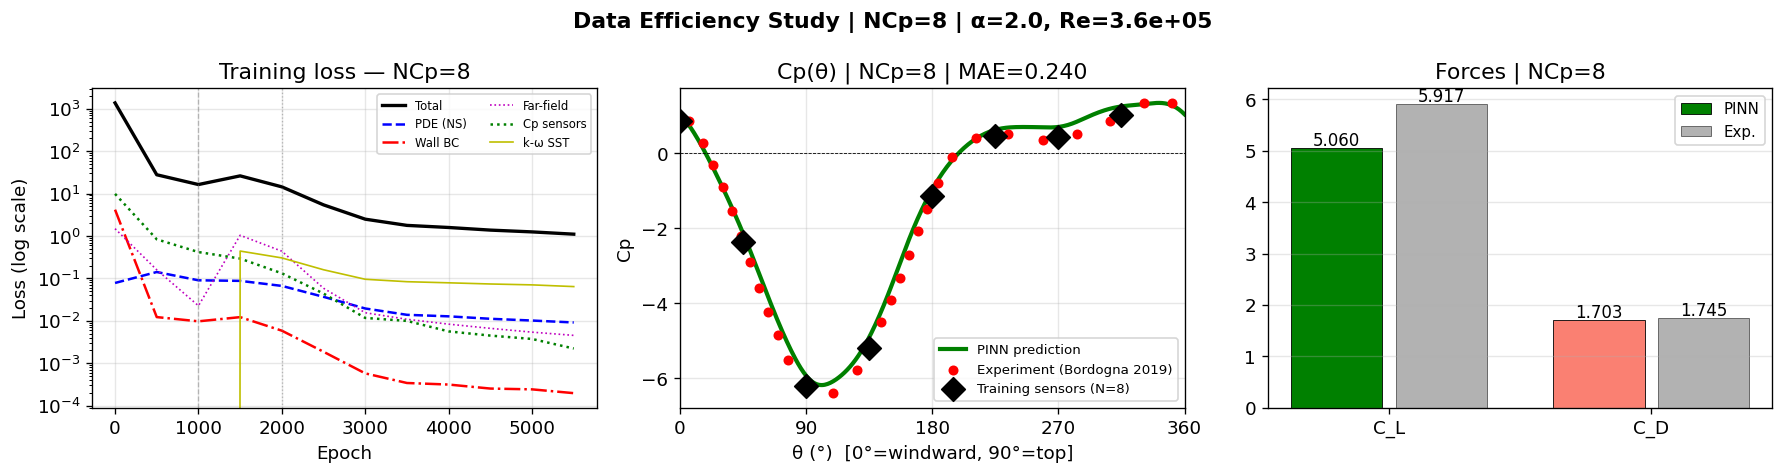

Saved: efficiency_8.png
  MAE=0.240  CL=5.060 (err=14.5%)  CD=1.703 (err=2.4%)



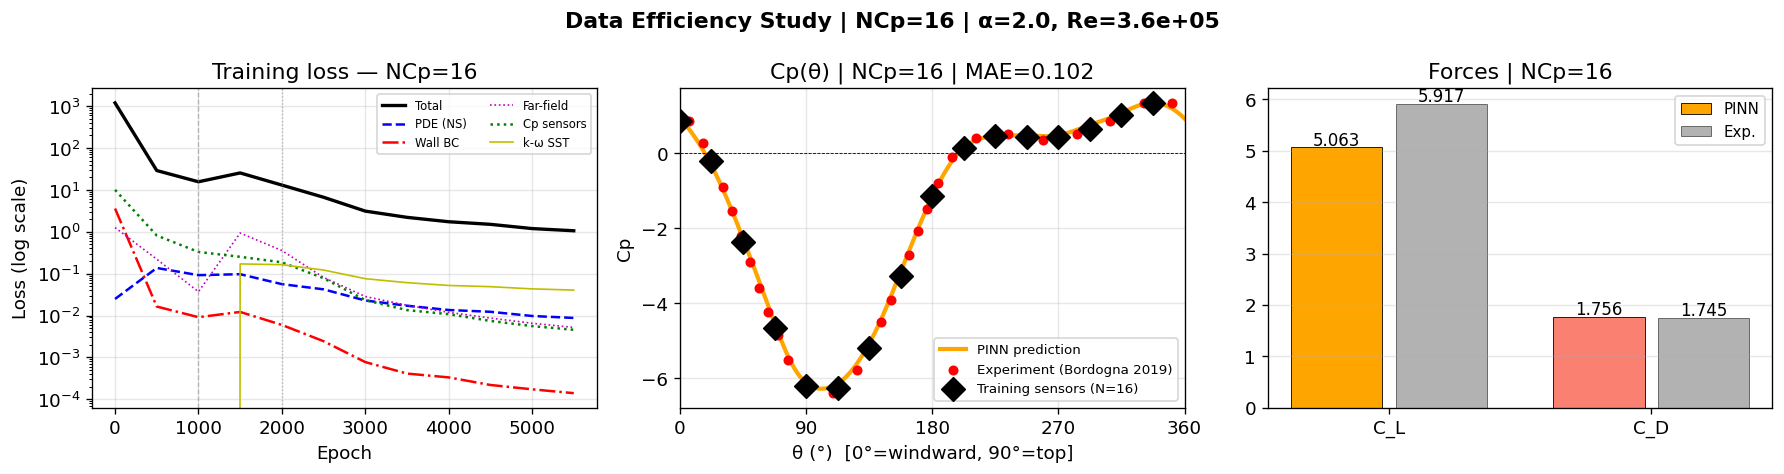

Saved: efficiency_16.png
  MAE=0.102  CL=5.063 (err=14.4%)  CD=1.756 (err=0.7%)



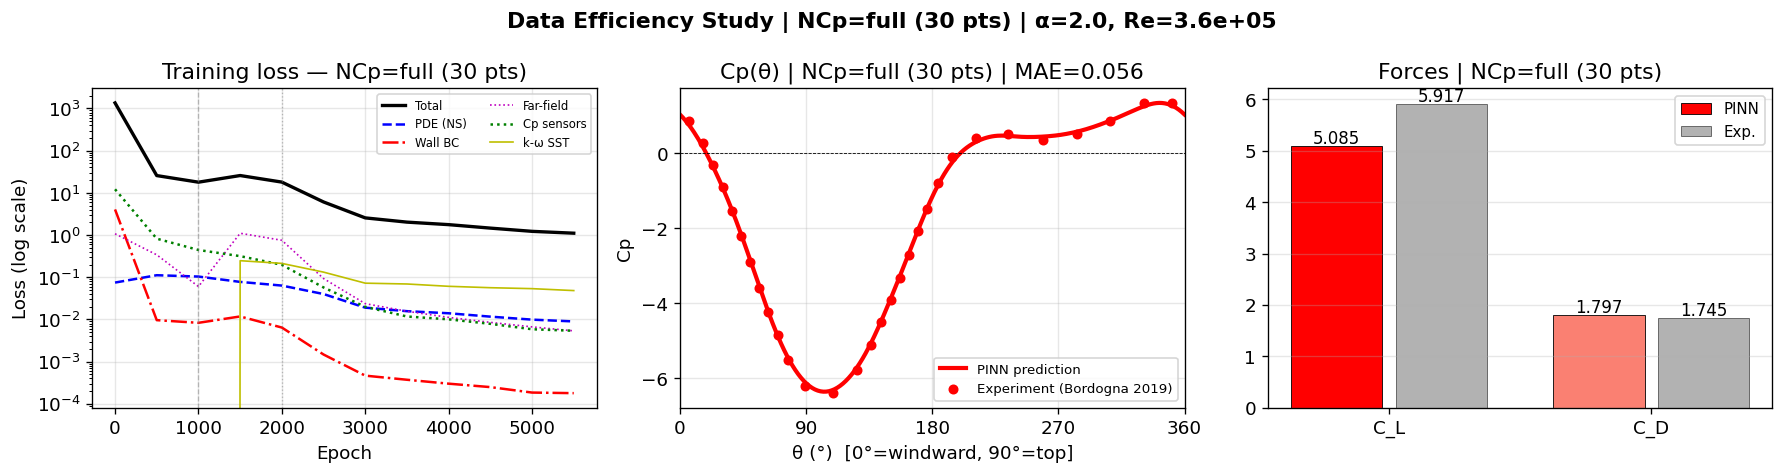

Saved: efficiency_full.png
  MAE=0.056  CL=5.085 (err=14.1%)  CD=1.797 (err=3.0%)



In [6]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5: PER-RUN PLOTS
# Each NCp condition gets identical 3-panel figure:
#   Panel 1: Training loss history
#   Panel 2: Cp(theta) with sensor markers
#   Panel 3: Force coefficient bars
# ─────────────────────────────────────────────────────────────────
import os as _os

# Reload from Drive if session restarted
import json as _json
RESULTS_FILE = f"{OUT_DIR}/data_efficiency_alpha{ALPHA}.json"
if "all_results" not in dir() or len(all_results) == 0:
    with open(RESULTS_FILE) as f:
        all_results = _json.load(f)
    for k in all_results:
        all_results[k]["Cp_pred"]       = np.array(all_results[k]["Cp_pred"])
        all_results[k]["th_deg"]        = np.array(all_results[k]["th_deg"])
        all_results[k]["sensor_angles"] = np.array(all_results[k]["sensor_angles"])
        all_results[k]["cp_values"]     = np.array(all_results[k]["cp_values"])
    print(f"Loaded {len(all_results)} results from Drive")

colors = {"0":"purple","4":"blue","8":"green","16":"orange","full":"red"}

for ncp_str, r in all_results.items():
    label        = r["label"]
    Cp_p         = r["Cp_pred"]
    th_p         = r["th_deg"]
    sensor_th    = r["sensor_angles"]
    sensor_cp    = r["cp_values"]
    hist         = r["history"]
    ep           = hist["epoch"]
    CL_p, CD_p  = r["CL"], r["CD"]
    mae          = r["mae"]
    col          = colors.get(ncp_str, "black")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # ── Panel 1: Training loss ────────────────────────────────────
    axes[0].semilogy(ep, hist["loss"],  "k-",  lw=2,   label="Total")
    axes[0].semilogy(ep, hist["pde"],   "b--", lw=1.5, label="PDE (NS)")
    axes[0].semilogy(ep, hist["wall"],  "r-.", lw=1.5, label="Wall BC")
    axes[0].semilogy(ep, hist["ff"],    "m:",  lw=1,   label="Far-field")
    axes[0].semilogy(ep, hist["cp"],    "g:",  lw=1.5, label="Cp sensors")
    axes[0].semilogy(ep, hist["turb"],  "y-",  lw=1,   label="k-ω SST")
    axes[0].axvline(1000, color="grey", lw=0.8, ls="--", alpha=0.5)
    axes[0].axvline(2000, color="grey", lw=0.8, ls=":",  alpha=0.5)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss (log scale)")
    axes[0].set_title(f"Training loss — {label}")
    axes[0].legend(fontsize=7, ncol=2)
    axes[0].grid(True, alpha=0.3)

    # ── Panel 2: Cp(theta) with sensor markers ────────────────────
    axes[1].plot(th_p, Cp_p, "-", color=col, lw=2.5, label="PINN prediction")
    axes[1].scatter(theta_exp, cp_exp, color="red", s=25, zorder=4,
                    label="Experiment (Bordogna 2019)")
    if len(sensor_th) > 0 and len(sensor_th) <= 16:
        axes[1].scatter(sensor_th, sensor_cp, color="black", s=100,
                        marker="D", zorder=5,
                        label=f"Training sensors (N={len(sensor_th)})")
    axes[1].axhline(0, color="k", lw=0.5, ls="--")
    axes[1].set_xlabel("θ (°)  [0°=windward, 90°=top]")
    axes[1].set_ylabel("Cp")
    axes[1].set_title(f"Cp(θ) | {label} | MAE={mae:.3f}")
    axes[1].set_xlim([0, 360])
    axes[1].set_xticks([0, 90, 180, 270, 360])
    axes[1].legend(fontsize=8)
    axes[1].grid(True, alpha=0.3)

    # ── Panel 3: Force coefficient bars ──────────────────────────
    x_pos = np.arange(2)
    axes[2].bar(x_pos-0.2, [CL_p, CD_p],   0.35, color=[col,"salmon"],
                label="PINN", edgecolor="k", lw=0.5)
    axes[2].bar(x_pos+0.2, [cl_ref, cd_ref],0.35, color=["grey","grey"],
                label="Exp.", alpha=0.6, edgecolor="k", lw=0.5)
    axes[2].set_xticks(x_pos)
    axes[2].set_xticklabels(["C_L", "C_D"])
    axes[2].set_title(f"Forces | {label}")
    for i,(pv,ev) in enumerate(zip([CL_p,CD_p],[cl_ref,cd_ref])):
        axes[2].text(i-0.2, max(pv,0)+0.05, f"{pv:.3f}", ha="center", fontsize=10)
        axes[2].text(i+0.2, max(ev,0)+0.05, f"{ev:.3f}", ha="center", fontsize=10)
    axes[2].axhline(0, color="k", lw=0.5)
    axes[2].legend(fontsize=9)
    axes[2].grid(True, alpha=0.3, axis="y")

    plt.suptitle(f"Data Efficiency Study | {label} | α={ALPHA}, Re={RE:.1e}",
                 fontweight="bold")
    plt.tight_layout()
    fname = f"{OUT_DIR}/efficiency_{ncp_str}.png"
    plt.savefig(fname, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {_os.path.basename(fname)}")
    print(f"  MAE={mae:.3f}  CL={CL_p:.3f} (err={abs(CL_p-cl_ref)/cl_ref*100:.1f}%)"
          f"  CD={CD_p:.3f} (err={abs(CD_p-cd_ref)/cd_ref*100:.1f}%)")
    print()


## Section 6 — Summary: MAE, CL, CD vs NCp


  DATA EFFICIENCY SUMMARY — α=2.0, Re=3.6e+05
  Label                  MAE      CL   CL err%      CD   CD err%
  --------------------------------------------------------------------
  NCp=0 (physics only)  3.381   0.038     99.4%  -0.019    101.1%
  NCp=4               0.373   4.666     21.1%   1.552     11.0%
  NCp=8               0.240   5.060     14.5%   1.703      2.4%
  NCp=16              0.102   5.063     14.4%   1.756      0.7%
  NCp=full (30 pts)   0.056   5.085     14.1%   1.797      3.0%
  --------------------------------------------------------------------
  Experiment ref:          CL=5.917             CD=1.745


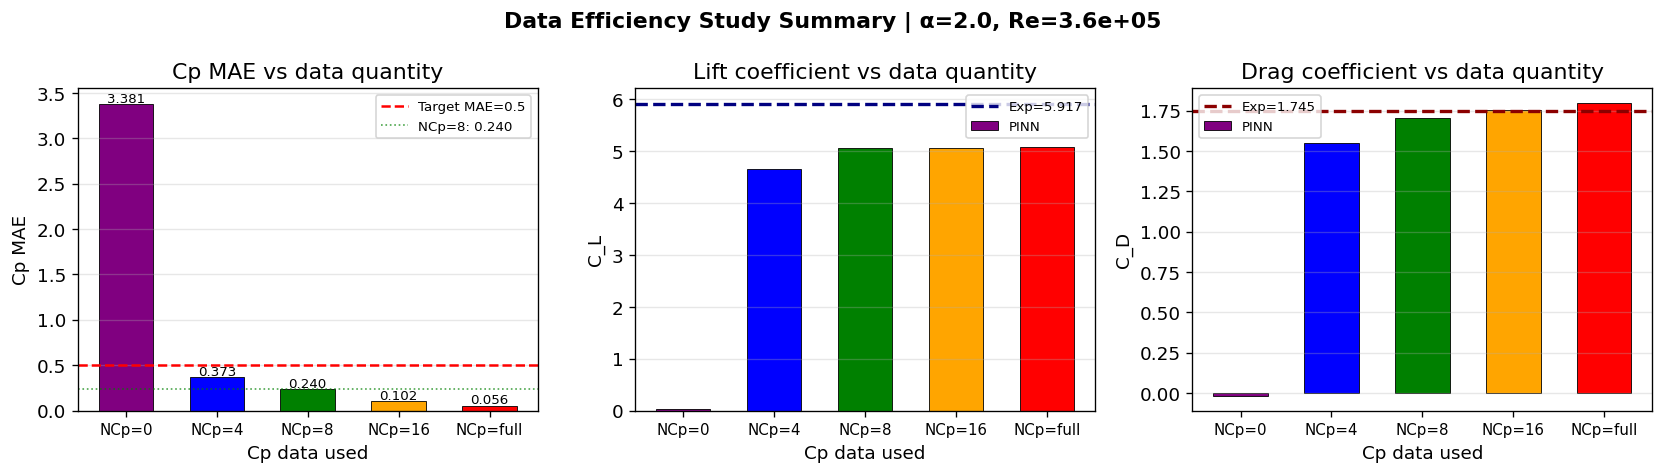

Summary figure saved ✓


In [9]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6: SUMMARY FIGURE AND TABLE
# Single figure comparing all NCp conditions.
# ─────────────────────────────────────────────────────────────────

# ── Summary table ────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  DATA EFFICIENCY SUMMARY — α={ALPHA}, Re={RE:.1e}")
print(f"{'='*70}")
print(f"  {'Label':<18} {'MAE':>7} {'CL':>7} {'CL err%':>9} {'CD':>7} {'CD err%':>9}")
print(f"  {'-'*68}")
for ncp_str, r in all_results.items():
    cl_e = abs(r["CL"]-cl_ref)/cl_ref*100
    cd_e = abs(r["CD"]-cd_ref)/cd_ref*100
    print(f"  {r['label']:<18} {r['mae']:>6.3f}  {r['CL']:>6.3f}  {cl_e:>7.1f}%"
          f"  {r['CD']:>6.3f}  {cd_e:>7.1f}%")
print(f"  {'-'*68}")
print(f"  Experiment ref:          CL={cl_ref:.3f}             CD={cd_ref:.3f}")
print(f"{'='*70}")

# ── Summary figure ────────────────────────────────────────────────
ncp_labels = [r["label"].split("(")[0].strip() for r in all_results.values()]
ncp_x      = list(range(len(all_results)))
maes  = [r["mae"] for r in all_results.values()]
cls   = [r["CL"]  for r in all_results.values()]
cds   = [r["CD"]  for r in all_results.values()]
bar_colors = list(colors.values())[:len(all_results)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# MAE
axes[0].bar(ncp_x, maes, color=bar_colors, width=0.6, edgecolor="k", lw=0.5)
axes[0].axhline(0.5, color="red", lw=1.5, ls="--", label="Target MAE=0.5")
axes[0].axhline(mae_ncp8 := maes[(list(all_results.keys()).index("8")) if "8" in all_results else 2],
                color="green", lw=1, ls=":", alpha=0.7, label=f"NCp=8: {maes[list(all_results.keys()).index('8') if '8' in all_results else 2]:.3f}")
axes[0].set_xticks(ncp_x); axes[0].set_xticklabels(ncp_labels, fontsize=9)
axes[0].set_xlabel("Cp data used"); axes[0].set_ylabel("Cp MAE")
axes[0].set_title("Cp MAE vs data quantity")
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3, axis="y")
for i,v in enumerate(maes):
    axes[0].text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=8)

# CL
axes[1].bar(ncp_x, cls, color=bar_colors, width=0.6, edgecolor="k", lw=0.5, label="PINN")
axes[1].axhline(cl_ref, color="navy", lw=2, ls="--", label=f"Exp={cl_ref:.3f}")
axes[1].set_xticks(ncp_x); axes[1].set_xticklabels(ncp_labels, fontsize=9)
axes[1].set_xlabel("Cp data used"); axes[1].set_ylabel("C_L")
axes[1].set_title("Lift coefficient vs data quantity")
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, axis="y")

# CD
axes[2].bar(ncp_x, cds, color=bar_colors, width=0.6, edgecolor="k", lw=0.5, label="PINN")
axes[2].axhline(cd_ref, color="darkred", lw=2, ls="--", label=f"Exp={cd_ref:.3f}")
axes[2].set_xticks(ncp_x); axes[2].set_xticklabels(ncp_labels, fontsize=9)
axes[2].set_xlabel("Cp data used"); axes[2].set_ylabel("C_D")
axes[2].set_title("Drag coefficient vs data quantity")
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle(f"Data Efficiency Study Summary | α={ALPHA}, Re={RE:.1e}",
             fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/efficiency_summary.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Summary figure saved ✓")